# Spatial distribution of deformation: heterogeneous case
In this experiment, instead of assuming the deformation is homogeneous throughout the outcrop, we measure the shear strain along a cross-section through the natural shear zone. This will lead to a spatially variant deformation. We will test (through forward modelling) whether this deformation can reproduce the strain pattern we see in the shear zone.

In [28]:
# Import the necessary libraries:
import numpy as np # linear algebra and numerical operations
import matplotlib.pyplot as plt # plotting library
from scipy.interpolate import CubicSpline # for cubic spline interpolation
from scipy.integrate import simpson

In [29]:
def compute_shear_strain_from_beta(beta):
    """
    If we know the angle of the long axis of a stretched marker w.r.t. the x-axis
    we can estimate the shear strain of the simple shear deformation.
    """
    return 2.0 / np.tan(2*np.radians(beta))

In [30]:
def generate_circle(center, radius):
    """
    Generates the x and y coordinates of a circle given a center and radius.
    """
    xy = [] # Python built-in list to hold the x and y coordinates of the circle

    for i in range(0, 360, 1):
        angle = np.radians(i)
        x = center[0] + radius * np.cos(angle)
        y = center[1] + radius * np.sin(angle)
        xy.append([x, y])

    return np.array(xy) # convert to np.array data type for easier manipulation

In [31]:
def apply_deformation(points, strain_profile):
    """
    Apply an inhomogeneous deformation to a set of points.
    The strain profile is the shear strain at various locations along the y-axis.
    """
    deformed_points = []

    # apply deformation to each point
    for xy in points:
        y = xy[1]
        gamma = strain_profile(y)
        F = np.array([[1.0, -gamma], [0.0, 1.0]])
        deformed_points.append(F @ xy)

    return np.array(deformed_points)

In [32]:
####################################################################
# mesure the beta angles at multiple locations 
positions = [-2.0, 0.0, 2.0] # measurement of position
betas = [30, 30, 30] # measurment of beta angles
####################################################################

4.618802153517008


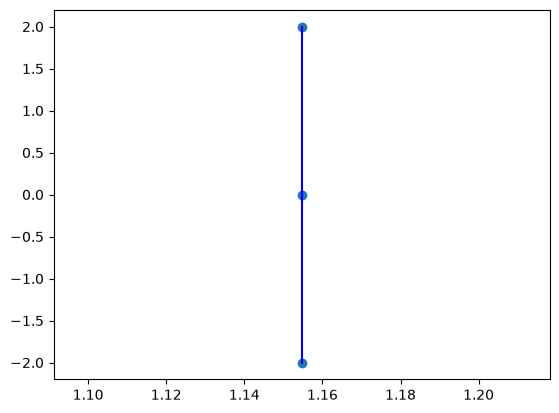

In [ ]:
gamma = [compute_shear_strain_from_beta(beta) for beta in betas]
cs = CubicSpline(positions, gamma) # Effectively a smooth curve connecting all measurement dots

# plot the strain profile for visualization
fig, ax = plt.subplots()
x = np.linspace(-2.0, 2.0, 100)
y = cs(x)
ax.plot(y, x, color='blue') # interpolated strain 
ax.scatter(gamma, positions) # measurements

##################################################################
# Compute displacement using numerical integration
# print(displacement)
##################################################################


<Figure size 640x480 with 0 Axes>

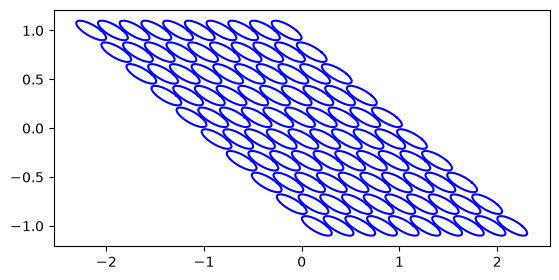

In [34]:
plt.clf()

x = np.linspace(-1.0, 1.0, 10)
y = np.linspace(-1.0, 1.0, 10)
X,Y = np.meshgrid(x,y)
fig, ax = plt.subplots()

for (x,y) in zip(X.flatten(), Y.flatten()):
    center = np.array([x,y])
    xy_circle = generate_circle(center, 0.1)
    xy_deformed = apply_deformation(xy_circle, cs)
    ax.plot(xy_deformed[:,0], xy_deformed[:,1], color='blue')

ax.set_aspect('equal', adjustable='box')

What does this tell us about the nature of strain distribution in a shear zone?